In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
file_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/data/lion_data_with_features.csv"
df = pd.read_csv(file_path)
df.head()

,longitude,latitude,lion_id,local_time,x,y,z,time_delta,movement_valid,dx,...,dz,distance,bearing,turn,bearing_sin,bearing_cos,turn_sin,turn_cos,hour_sin,hour_cos
0,22.743923,-21.286270,1001,2009-12-07 22:00:00,0.859325,0.360238,-0.363028,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.500000,0.866025
1,22.743892,-21.286279,1001,2009-12-07 23:00:00,0.859325,0.360237,-0.363028,0 days 01:00:00,True,1.423170e-07,...,-1.463634e-07,5.280452e-07,-1.286473,NaN,-0.959852,0.280508,NaN,NaN,-0.258819,0.965926
2,22.743804,-21.286048,1001,2009-12-08 00:00:00,0.859327,0.360236,-0.363024,0 days 01:00:00,True,1.903094e-06,...,3.756663e-06,4.278173e-06,-0.377214,0.909260,-0.368332,0.929694,0.789049,0.614330,0.000000,1.000000
3,22.744277,-21.287271,1001,2009-12-08 01:00:00,0.859317,0.360241,-0.363044,0 days 01:00:00,True,-1.012046e-05,...,-1.988911e-05,2.268909e-05,2.756839,3.134053,0.375331,-0.926891,0.007540,-0.999972,0.258819,0.965926
4,22.744216,-21.287307,1001,2009-12-08 02:00:00,0.859317,0.360240,-0.363045,0 days 01:00:00,True,1.731600e-07,...,-5.854495e-07,1.174253e-06,-1.399850,2.126497,-0.985424,0.170115,0.849531,-0.527538,0.500000,0.866025


In [9]:
print(df.shape)

(99271, 21)


In [4]:
import numpy as np
labels_kmeans = np.load("/content/drive/MyDrive/Lion-Biologging-SoS'26/features/labels_kmeans.npy")

In [10]:
#defining constants
window_size = 24 #because lion have circadian rythm (24hr cycle)
stride = 1 #window moves forward 1hour at a time

In [27]:

X_sequences = []

for lion_id, lion_sub_df in df.groupby('lion_id'):
  total_rows = len(lion_sub_df)
  stopping_point = total_rows - window_size + 1

  for i in range(0,stopping_point,stride):
    window = lion_sub_df.iloc[i:i+window_size]

    if not window['movement_valid'].all():
      continue

    filtered_window = window[['distance', 'dx','dy','dz','turn']]
    filtered_window = filtered_window.dropna()
    distance_mean = filtered_window['distance'].mean()
    dx_var = filtered_window['dx'].var()
    dy_var = filtered_window['dy'].var()
    dz_var = filtered_window['dz'].var()
    turn_var = filtered_window['turn'].var()

    features = [distance_mean, dx_var, dy_var, dz_var, turn_var]
    X_sequences.append(features)

In [31]:
df_summary = pd.DataFrame(X_sequences, columns=['distance_mean', 'dx_var', 'dy_var', 'dz_var', 'turn_var'])

df_summary = df_summary.dropna()

df_summary = df_summary.iloc[:-1]
df_summary['Cluster'] = labels_kmeans

print("DataFrame Shape:", df_summary.shape)

df_summary.head()


DataFrame Shape: (15952, 6)


,distance_mean,dx_var,dy_var,dz_var,turn_var,Cluster
0,0.000039,2.165023e-09,3.644655e-09,2.898543e-09,2.618362,3
1,0.000033,1.982146e-09,3.605593e-09,2.235792e-09,2.522717,3
2,0.000021,1.017195e-09,1.406908e-09,1.506095e-09,2.753134,3
3,0.000022,1.015387e-09,1.403744e-09,1.504438e-09,2.755821,1
4,0.000020,1.003975e-09,1.398375e-09,1.473401e-09,2.359527,1


In [32]:
df_profile = df_summary.groupby('Cluster').mean()

df_profile

,distance_mean,dx_var,dy_var,dz_var,turn_var
Cluster,,,,,
0,0.000058,2.313357e-09,7.684003e-09,6.235415e-09,3.817892
1,0.000058,2.264221e-09,7.696111e-09,5.945394e-09,3.724376
2,0.000059,2.355801e-09,7.796204e-09,6.251329e-09,3.760125
3,0.000057,2.226656e-09,7.611463e-09,5.959002e-09,3.830523


/tmp/ipykernel_1888/3226315244.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_profile.index, y='distance_mean', data=df_profile, ax=axes[0, 0],palette ='viridis')
/tmp/ipykernel_1888/3226315244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_profile.index, y='dz_var', data=df_profile, ax=axes[0, 1],palette ='viridis')
/tmp/ipykernel_1888/3226315244.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_profile.index, y='dy_var', data=df_profile, ax=axes[1, 0],palette ='viridis')
/tmp/ipykernel_1888/3226315244.py:23: Fu

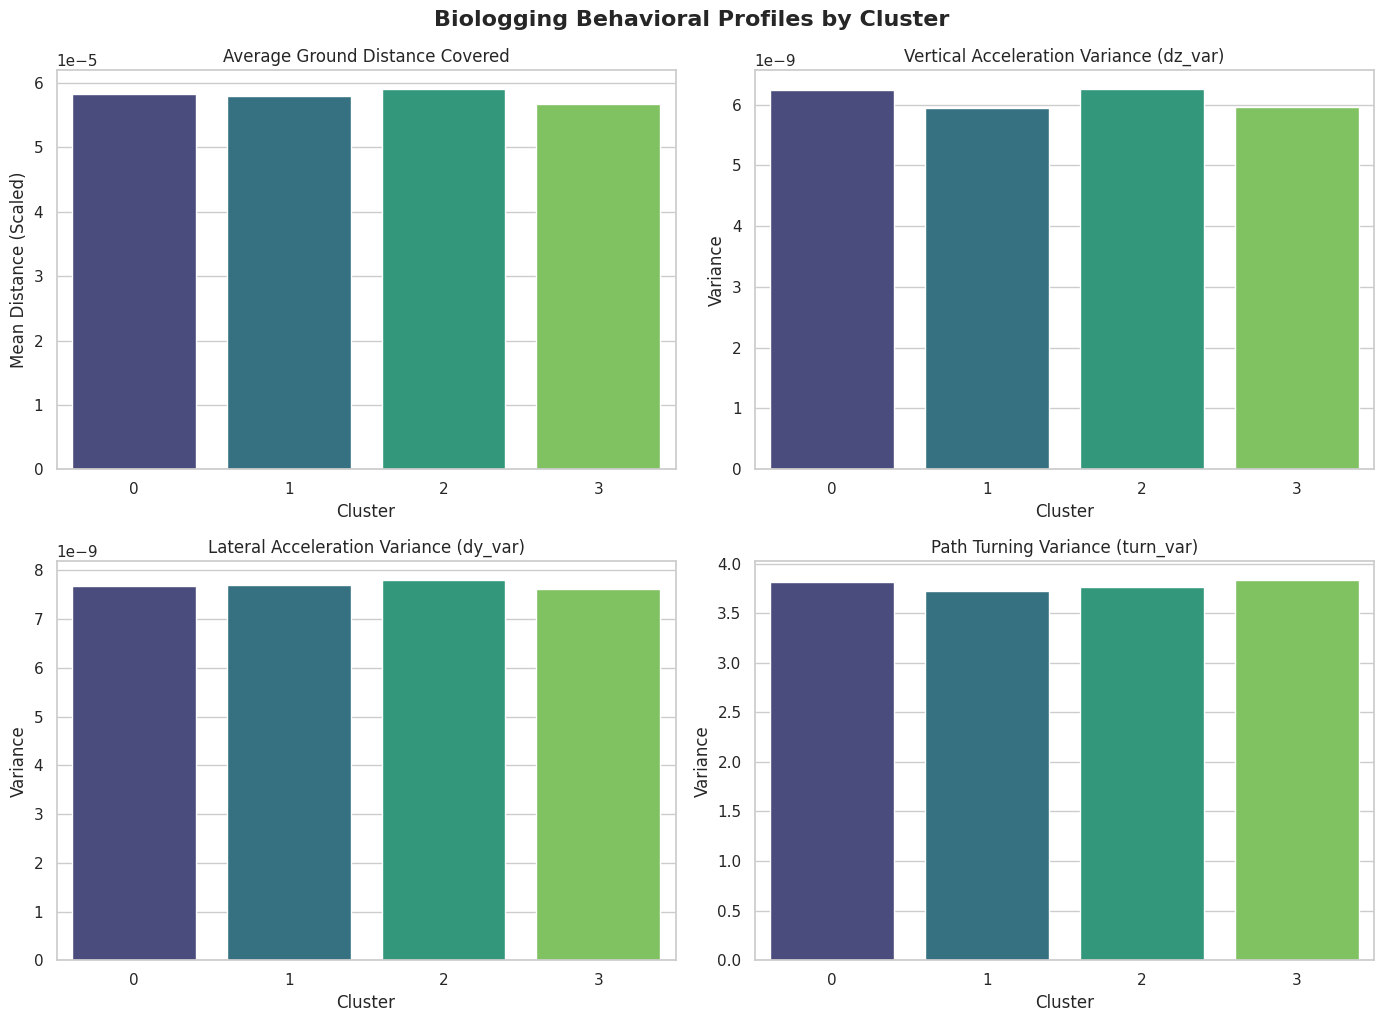

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Distance Mean Plot
sns.barplot(x=df_profile.index, y='distance_mean', data=df_profile, ax=axes[0, 0],palette ='viridis')
axes[0, 0].set_title('Average Ground Distance Covered')
axes[0, 0].set_ylabel('Mean Distance (Scaled)')

# Vertical Acceleration Variance Plot (Body Exertion)
sns.barplot(x=df_profile.index, y='dz_var', data=df_profile, ax=axes[0, 1],palette ='viridis')
axes[0, 1].set_title('Vertical Acceleration Variance (dz_var)')
axes[0, 1].set_ylabel('Variance')

# Horizontal Acceleration Variance Plot (Lateral Movement)
sns.barplot(x=df_profile.index, y='dy_var', data=df_profile, ax=axes[1, 0],palette ='viridis')
axes[1, 0].set_title('Lateral Acceleration Variance (dy_var)')
axes[1, 0].set_ylabel('Variance')

# Turning Variance Plot (Path Complexity)
sns.barplot(x=df_profile.index, y='turn_var', data=df_profile, ax=axes[1, 1],palette ='viridis')
axes[1, 1].set_title('Path Turning Variance (turn_var)')
axes[1, 1].set_ylabel('Variance')

# Adjust layout for a clean finish
plt.tight_layout()
plt.suptitle('Biologging Behavioral Profiles by Cluster', y=1.02, fontsize=16, fontweight='bold')

graph_save_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/images/behavioral_profiles_dashboard.png"
plt.savefig(graph_save_path, bbox_inches='tight', dpi=300)

plt.show()

In [43]:
summary_save_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/data/lion_window_summaries_with_clusters.csv"
profile_save_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/data/lion_cluster_profiles.csv"

df_summary.to_csv(summary_save_path, index=False)
df_profile.to_csv(profile_save_path, index=True)